# SentinelGPT: Pure Data Pipeline (Fixed V2)

**Changelog:**
- Fixed `TrustAIRLab` loading by selecting the `jailbreak_2023_12_25` configuration.
- Fixed `XSTest` loading by selecting the `prompts` split.
- Fixed Seaborn visualization warnings.

In [9]:
!pip install datasets pandas matplotlib seaborn wordcloud

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Set Plot Style
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Morphological Attacks (Deepset)

In [11]:
print("Loading Deepset Prompt Injections...")
try:
    ds_deepset = load_dataset("deepset/prompt-injections", split="train")
    df_deepset = ds_deepset.to_pandas()
    df_deepset = df_deepset[['text', 'label']]
    df_deepset['source'] = 'deepset_injection'
    print(f"✅ Success: {len(df_deepset)} samples")
except Exception as e:
    print(f"❌ Error loading Deepset: {e}")

Loading Deepset Prompt Injections...
✅ Success: 546 samples


## 2. Load Social Engineering (TrustAIRLab)
**Fix:** Selecting `jailbreak_2023_12_25` to get the latest attack patterns.

In [12]:
print("Loading In-The-Wild Jailbreaks (TrustAIRLab)...")
try:
    # FIX: Added configuration name 'jailbreak_2023_12_25'
    ds_wild = load_dataset("TrustAIRLab/in-the-wild-jailbreak-prompts", "jailbreak_2023_12_25", split="train")
    df_wild = ds_wild.to_pandas()
    
    if 'prompt' in df_wild.columns:
        df_wild = df_wild.rename(columns={'prompt': 'text'})
    
    df_wild['label'] = 1
    df_wild['source'] = 'trustairlab_wild'
    df_wild = df_wild[['text', 'label', 'source']]
    
    print(f"✅ Success: {len(df_wild)} samples")
except Exception as e:
    print(f"❌ Error loading TrustAIRLab: {e}")

Loading In-The-Wild Jailbreaks (TrustAIRLab)...


jailbreak_2023_12_25/train-00000-of-0000(…):   0%|          | 0.00/1.87M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1405 [00:00<?, ? examples/s]

✅ Success: 1405 samples


## 3. Load Hard Negatives (XSTest)
**Fix:** Selecting `prompts` split instead of `train`.

In [13]:
print("Loading XSTest (Hard Negatives)...")
try:
    # FIX: Changed split from 'train' to 'prompts'
    ds_xs = load_dataset("natolambert/xstest-v2-copy", split="prompts")
    df_xs = ds_xs.to_pandas()
    df_xs = df_xs.rename(columns={'prompt': 'text'})
    df_xs['label'] = 0 # Safe
    df_xs['source'] = 'xstest_hard_negative'
    df_xs = df_xs[['text', 'label', 'source']]
    print(f"✅ Success: {len(df_xs)} samples")
except Exception as e:
    print(f"❌ Error loading XSTest: {e}")

Loading XSTest (Hard Negatives)...
✅ Success: 450 samples


## 4. Load General Safe Baseline (Alpaca)

In [14]:
print("Loading Alpaca (General Safe)...")
try:
    ds_alpaca = load_dataset("tatsu-lab/alpaca", split="train")
    df_alpaca = ds_alpaca.to_pandas()
    df_alpaca['text'] = df_alpaca['instruction'] + " " + df_alpaca['input']
    df_alpaca = df_alpaca[['text']]
    df_alpaca['label'] = 0
    df_alpaca['source'] = 'alpaca_general'
    
    # Balancing: Taking 20k samples
    df_alpaca = df_alpaca.sample(n=20000, random_state=42)
    print(f"✅ Success: {len(df_alpaca)} samples")
except Exception as e:
    print(f"❌ Error loading Alpaca: {e}")

Loading Alpaca (General Safe)...
✅ Success: 20000 samples


## 5. Merge, Clean, and Save


🎉 Final Dataset Ready: 22401 rows


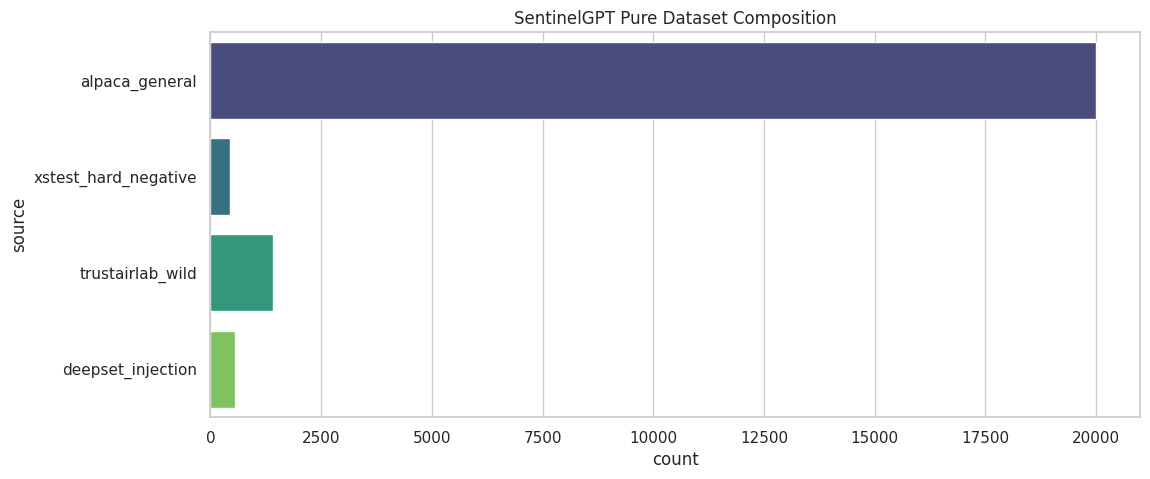

In [15]:
possible_vars = ['df_deepset', 'df_wild', 'df_xs', 'df_alpaca']
dfs_to_merge = []

for var_name in possible_vars:
    if var_name in locals() and isinstance(locals()[var_name], pd.DataFrame):
        dfs_to_merge.append(locals()[var_name])
    elif var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        dfs_to_merge.append(globals()[var_name])

if not dfs_to_merge:
    print("❌ Critical Error: No datasets loaded.")
else:
    combined_df = pd.concat(dfs_to_merge, ignore_index=True)
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Clean empty strings
    combined_df = combined_df[combined_df['text'].str.strip().astype(bool)]
    
    print(f"\n🎉 Final Dataset Ready: {len(combined_df)} rows")
    
    # Updated Plot to fix warning
    plt.figure(figsize=(12, 5))
    sns.countplot(y='source', hue='source', data=combined_df, palette='viridis', legend=False)
    plt.title('SentinelGPT Pure Dataset Composition')
    plt.show()

In [16]:
output_name = "sentinelgpt_pure_dataset.pkl"
combined_df.to_pickle(output_name)
combined_df.to_csv("sentinelgpt_pure_dataset.csv", index=False)
print(f"✅ Dataset saved to {output_name}")

✅ Dataset saved to sentinelgpt_pure_dataset.pkl
